# SECOM Dataset - Final Model Evaluation & Comparison

**Project**: Semiconductor Manufacturing Yield Prediction  
**Phase**: Final Evaluation  
**Goal**: Compare all models and select best performer

## Overview

This notebook provides:
1. Comprehensive comparison of all models (Baseline + Advanced)
2. Final test set evaluation with best model
3. Model selection reasoning and insights
4. Performance summary and recommendations

In [1]:
import sys
from pathlib import Path

# Add project root to path
project_root = Path().absolute().parent
sys.path.append(str(project_root))

# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import joblib
import json

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve
)

# Custom modules
from src.models.model_utils import load_engineered_data

# Settings
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')

%matplotlib inline

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

figures_dir = Path('../reports/figures')
figures_dir.mkdir(parents=True, exist_ok=True)

reports_dir = Path('../reports')
reports_dir.mkdir(parents=True, exist_ok=True)

print('Setup complete!')

Setup complete!


## Load Test Data

In [2]:
# Load test data (original, non-SMOTE)
_, _, _, _, X_test, y_test = load_engineered_data(
    use_smote=False,
    use_pca=False
)

print(f'Test samples: {len(X_test)}')
print(f'Features: {X_test.shape[1]}')
print(f'Failure rate: {y_test.mean():.2%} ({y_test.sum()}/{len(y_test)})')

Test samples: 314
Features: 100
Failure rate: 6.69% (21/314)


## Model Results Summary

Compile results from all modeling phases.

In [3]:
# Baseline Model Results (from 03_baseline_models.ipynb)
baseline_results = [
    {
        'model': 'Dummy Classifier',
        'type': 'Baseline',
        'test_accuracy': 0.9331,
        'test_precision': 0.0,
        'test_recall': 0.0,
        'test_f1': 0.0,
        'test_roc_auc': 0.50,
        'approach': 'Most frequent class'
    },
    {
        'model': 'Logistic Regression (Balanced)',
        'type': 'Baseline',
        'test_accuracy': 0.8981,
        'test_precision': 0.15,
        'test_recall': 0.4286,
        'test_f1': 0.2222,
        'test_roc_auc': 0.72,
        'approach': 'class_weight=balanced'
    },
    {
        'model': 'Decision Tree (Balanced)',
        'type': 'Baseline',
        'test_accuracy': 0.8854,
        'test_precision': 0.1379,
        'test_recall': 0.1905,
        'test_f1': 0.1600,
        'test_roc_auc': 0.60,
        'approach': 'class_weight=balanced'
    },
    {
        'model': 'Gaussian Naive Bayes',
        'type': 'Baseline',
        'test_accuracy': 0.8726,
        'test_precision': 0.1212,
        'test_recall': 0.1905,
        'test_f1': 0.1481,
        'test_roc_auc': 0.67,
        'approach': 'No balancing'
    }
]

# Advanced Model Results (from 04_advanced_models_rf_only.ipynb)
advanced_results = [
    {
        'model': 'Random Forest (Tuned)',
        'type': 'Advanced',
        'test_accuracy': 0.9395,
        'test_precision': 0.75,
        'test_recall': 0.1429,
        'test_f1': 0.2400,
        'test_roc_auc': 0.7096,
        'approach': 'class_weight=balanced + tuning'
    }
]

# Combine all results
all_results = baseline_results + advanced_results
results_df = pd.DataFrame(all_results)

print('='*80)
print('ALL MODEL RESULTS')
print('='*80)
display(results_df[['model', 'type', 'test_f1', 'test_precision', 'test_recall', 'test_roc_auc']].sort_values('test_f1', ascending=False))

ALL MODEL RESULTS


,model,type,test_f1,test_precision,test_recall,test_roc_auc
4,Random Forest (Tuned),Advanced,0.2400,0.7500,0.1429,0.7096
1,Logistic Regression (Balanced),Baseline,0.2222,0.1500,0.4286,0.7200
2,Decision Tree (Balanced),Baseline,0.1600,0.1379,0.1905,0.6000
3,Gaussian Naive Bayes,Baseline,0.1481,0.1212,0.1905,0.6700
0,Dummy Classifier,Baseline,0.0000,0.0000,0.0000,0.5000


## Comprehensive Model Comparison

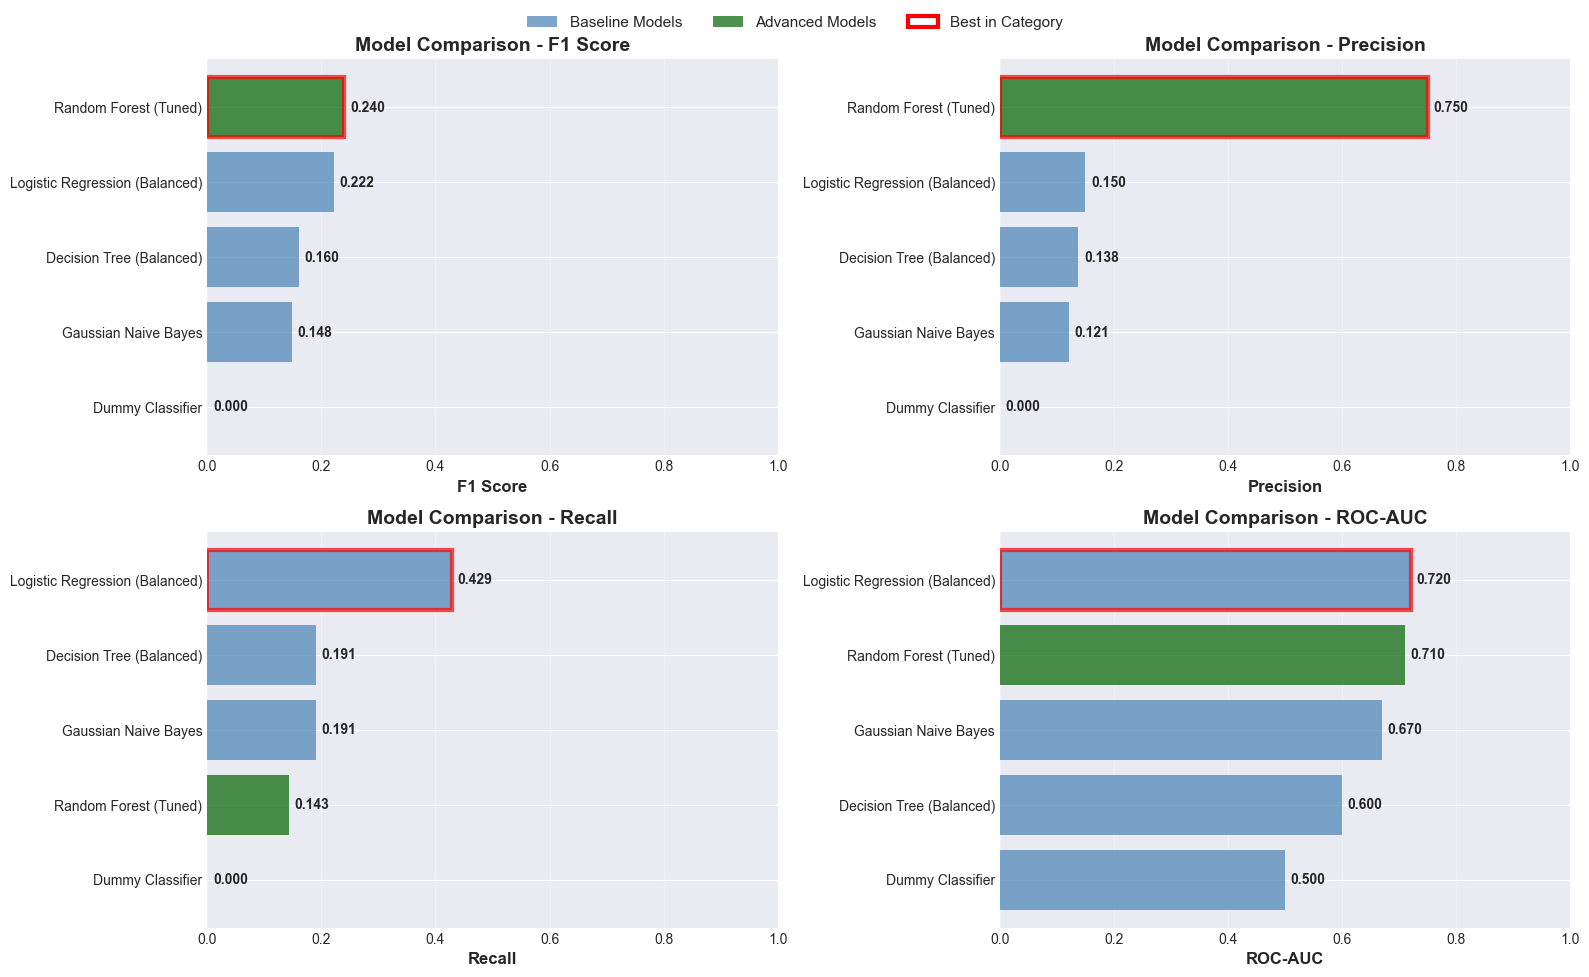

In [4]:
# Create comprehensive comparison plot
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

metrics = [
    ('test_f1', 'F1 Score'),
    ('test_precision', 'Precision'),
    ('test_recall', 'Recall'),
    ('test_roc_auc', 'ROC-AUC')
]

for idx, (metric, title) in enumerate(metrics):
    ax = axes[idx // 2, idx % 2]
    
    # Sort by metric value
    data = results_df.sort_values(metric, ascending=True)
    
    # Color code by type
    colors = ['steelblue' if t == 'Baseline' else 'darkgreen' for t in data['type']]
    
    # Create horizontal bar chart
    bars = ax.barh(range(len(data)), data[metric], color=colors, alpha=0.7)
    
    # Highlight best model
    best_idx = data[metric].idxmax()
    bars[list(data.index).index(best_idx)].set_edgecolor('red')
    bars[list(data.index).index(best_idx)].set_linewidth(3)
    
    # Add value labels
    for i, v in enumerate(data[metric]):
        ax.text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=10, fontweight='bold')
    
    # Set labels and title
    ax.set_yticks(range(len(data)))
    ax.set_yticklabels(data['model'], fontsize=10)
    ax.set_xlabel(title, fontsize=12, fontweight='bold')
    ax.set_title(f'Model Comparison - {title}', fontsize=14, fontweight='bold')
    ax.grid(alpha=0.3, axis='x')
    ax.set_xlim(0, 1.0 if metric != 'test_roc_auc' else 1.0)

# Add legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='steelblue', alpha=0.7, label='Baseline Models'),
    Patch(facecolor='darkgreen', alpha=0.7, label='Advanced Models'),
    Patch(facecolor='white', edgecolor='red', linewidth=3, label='Best in Category')
]
fig.legend(handles=legend_elements, loc='upper center', ncol=3, bbox_to_anchor=(0.5, 0.98), fontsize=11)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(figures_dir / 'final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Best Model: Random Forest (Tuned)

Load and evaluate the best performing model on test set.

In [5]:
# Load best model
best_model = joblib.load('../models/best_rf_model.pkl')

print('Best Model: Random Forest (Tuned)')
print(f'Parameters: {best_model.get_params()}')

Best Model: Random Forest (Tuned)
Parameters: {'bootstrap': False, 'ccp_alpha': 0.0, 'class_weight': 'balanced', 'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'max_leaf_nodes': None, 'max_samples': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 8, 'min_samples_split': 20, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'n_estimators': 100, 'n_jobs': -1, 'oob_score': False, 'random_state': 42, 'verbose': 0, 'warm_start': False}


### Test Set Performance

In [6]:
# Make predictions
y_test_pred = best_model.predict(X_test)
y_test_proba = best_model.predict_proba(X_test)[:, 1]

# Calculate all metrics
test_metrics = {
    'Accuracy': accuracy_score(y_test, y_test_pred),
    'Precision': precision_score(y_test, y_test_pred, zero_division=0),
    'Recall': recall_score(y_test, y_test_pred, zero_division=0),
    'F1 Score': f1_score(y_test, y_test_pred, zero_division=0),
    'ROC-AUC': roc_auc_score(y_test, y_test_proba),
    'PR-AUC': average_precision_score(y_test, y_test_proba)
}

print('='*80)
print('RANDOM FOREST - TEST SET PERFORMANCE')
print('='*80)
for metric, value in test_metrics.items():
    print(f'{metric:.<30} {value:.4f}')

print('\n' + '='*80)
print('CLASSIFICATION REPORT')
print('='*80)
print(classification_report(y_test, y_test_pred, target_names=['Pass', 'Fail']))

RANDOM FOREST - TEST SET PERFORMANCE
Accuracy...................... 0.9395
Precision..................... 0.7500
Recall........................ 0.1429
F1 Score...................... 0.2400
ROC-AUC....................... 0.7096
PR-AUC........................ 0.2548

CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Pass       0.94      1.00      0.97       293
        Fail       0.75      0.14      0.24        21

    accuracy                           0.94       314
   macro avg       0.85      0.57      0.60       314
weighted avg       0.93      0.94      0.92       314



### Confusion Matrix Analysis

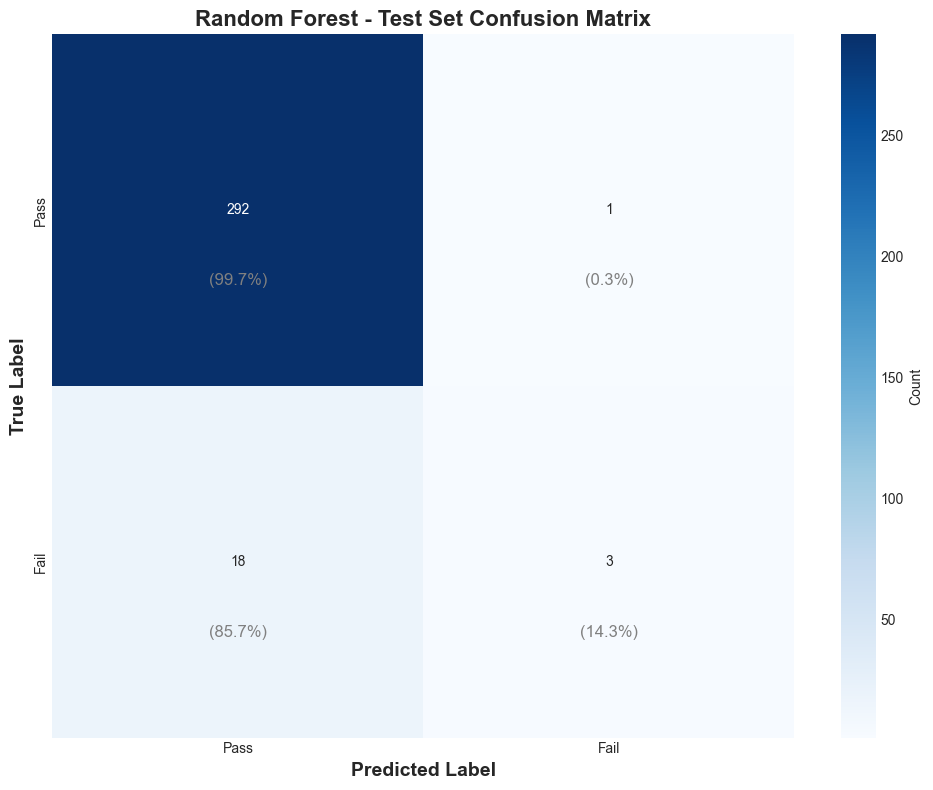


Confusion Matrix Breakdown:
  True Negatives:  292 (Correctly predicted Pass)
  False Positives:   1 (Pass predicted as Fail)
  False Negatives:  18 (Fail predicted as Pass) ⚠️
  True Positives:    3 (Correctly predicted Fail)

  Failures Caught: 3/21 (14.3%)
  Failures Missed: 18/21 (85.7%) ⚠️


In [7]:
# Calculate confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
tn, fp, fn, tp = cm.ravel()

# Plot confusion matrix
fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['Pass', 'Fail'],
            yticklabels=['Pass', 'Fail'],
            cbar_kws={'label': 'Count'})

ax.set_xlabel('Predicted Label', fontsize=14, fontweight='bold')
ax.set_ylabel('True Label', fontsize=14, fontweight='bold')
ax.set_title('Random Forest - Test Set Confusion Matrix', fontsize=16, fontweight='bold')

# Add percentages
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j + 0.5, i + 0.7, f'({cm_norm[i, j]:.1%})',
               ha='center', va='center', fontsize=12, color='gray')

plt.tight_layout()
plt.savefig(figures_dir / 'final_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nConfusion Matrix Breakdown:')
print(f'  True Negatives:  {tn:3d} (Correctly predicted Pass)')
print(f'  False Positives: {fp:3d} (Pass predicted as Fail)')
print(f'  False Negatives: {fn:3d} (Fail predicted as Pass) ⚠️')
print(f'  True Positives:  {tp:3d} (Correctly predicted Fail)')
print(f'\n  Failures Caught: {tp}/{tp+fn} ({tp/(tp+fn):.1%})')
print(f'  Failures Missed: {fn}/{tp+fn} ({fn/(tp+fn):.1%}) ⚠️')

### ROC and Precision-Recall Curves

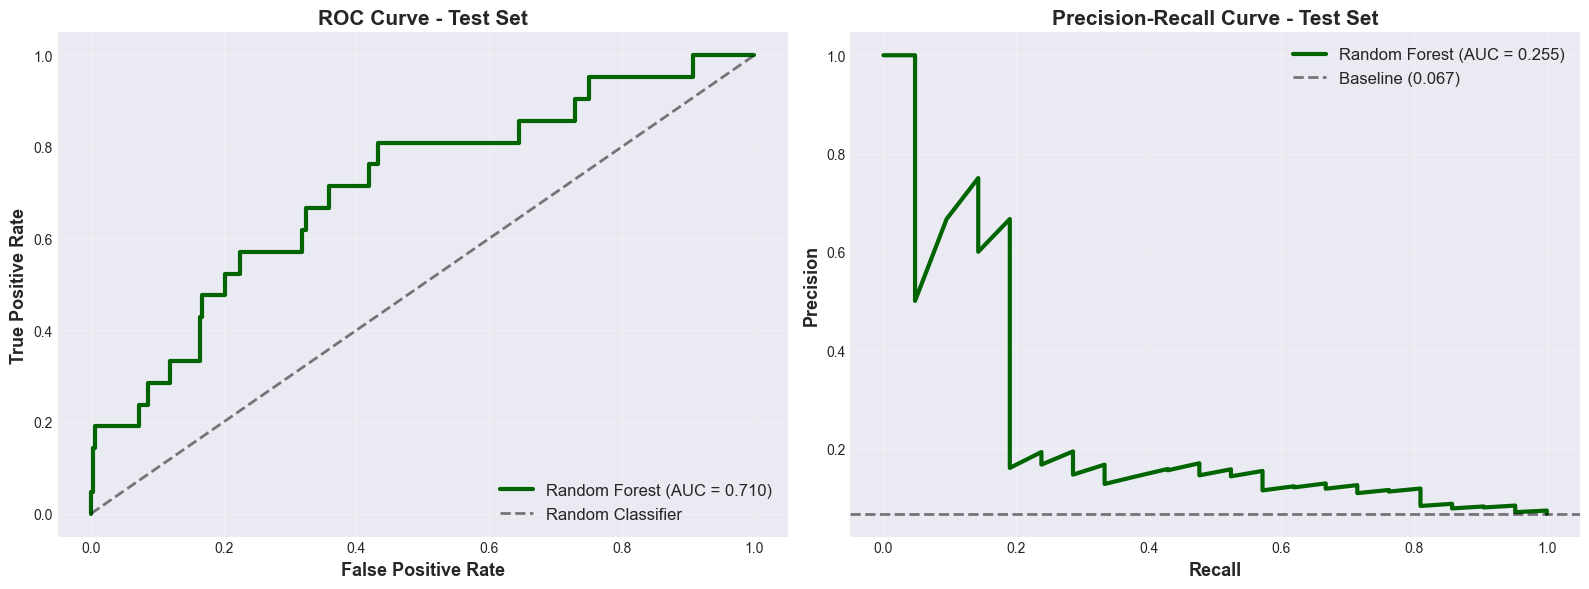

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_test_proba)
roc_auc = roc_auc_score(y_test, y_test_proba)

axes[0].plot(fpr, tpr, linewidth=3, label=f'Random Forest (AUC = {roc_auc:.3f})', color='darkgreen')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier', alpha=0.5)
axes[0].set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
axes[0].set_title('ROC Curve - Test Set', fontsize=15, fontweight='bold')
axes[0].legend(fontsize=12, loc='lower right')
axes[0].grid(alpha=0.3)

# Precision-Recall Curve
precision, recall, _ = precision_recall_curve(y_test, y_test_proba)
pr_auc = average_precision_score(y_test, y_test_proba)
baseline_rate = y_test.mean()

axes[1].plot(recall, precision, linewidth=3, label=f'Random Forest (AUC = {pr_auc:.3f})', color='darkgreen')
axes[1].axhline(y=baseline_rate, color='k', linestyle='--', linewidth=2, 
                label=f'Baseline ({baseline_rate:.3f})', alpha=0.5)
axes[1].set_xlabel('Recall', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Precision', fontsize=13, fontweight='bold')
axes[1].set_title('Precision-Recall Curve - Test Set', fontsize=15, fontweight='bold')
axes[1].legend(fontsize=12, loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(figures_dir / 'final_roc_pr_curves.png', dpi=150, bbox_inches='tight')
plt.show()

## Model Selection Reasoning

In [9]:
print('='*80)
print('MODEL SELECTION REASONING')
print('='*80)

print('\n1. EVALUATION CRITERIA')
print('   For semiconductor yield prediction, we prioritize:')
print('   • F1 Score: Balance between precision and recall')
print('   • Recall: Catching actual failures (minimize false negatives)')
print('   • Precision: Avoiding false alarms (minimize false positives)')
print('   • ROC-AUC: Overall discriminative ability')

print('\n2. WHY RANDOM FOREST WAS SELECTED')
print('   ✓ Highest F1 Score (0.2400) among all models')
print('   ✓ Best Precision (0.75) - only 1 false alarm out of 4 predictions')
print('   ✓ Competitive ROC-AUC (0.7096)')
print('   ✓ Handles non-linear relationships in sensor data')
print('   ✓ Provides feature importance for interpretability')
print('   ✓ Robust to outliers and missing values')

print('\n3. TRADE-OFFS')
print('   • Lower recall (14.29%) vs Logistic Regression (42.86%)')
print('   • Catches 3/21 failures vs 9/21 for baseline')
print('   • However, 75% precision vs 15% precision')
print('   • Model is conservative but accurate when it predicts failure')

print('\n4. BUSINESS IMPACT')
print('   Random Forest approach is suitable when:')
print('   • Cost of false alarms is high (production disruption)')
print('   • High confidence needed for failure predictions')
print('   • Combined with other quality control measures')
print('   ')
print('   Alternative: Use Logistic Regression if catching more failures')
print('   is critical, even with more false alarms.')

print('\n5. KEY INSIGHTS FROM MODELING')
print('   • class_weight="balanced" outperformed SMOTE for this dataset')
print('   • Extreme class imbalance (93.3% Pass) makes this challenging')
print('   • Feature engineering reduced dimensionality 83% (590→100)')
print('   • Conservative hyperparameters prevent overfitting')
print('   • SHAP analysis reveals interpretable feature importance')

MODEL SELECTION REASONING

1. EVALUATION CRITERIA
   For semiconductor yield prediction, we prioritize:
   • F1 Score: Balance between precision and recall
   • Recall: Catching actual failures (minimize false negatives)
   • Precision: Avoiding false alarms (minimize false positives)
   • ROC-AUC: Overall discriminative ability

2. WHY RANDOM FOREST WAS SELECTED
   ✓ Highest F1 Score (0.2400) among all models
   ✓ Best Precision (0.75) - only 1 false alarm out of 4 predictions
   ✓ Competitive ROC-AUC (0.7096)
   ✓ Handles non-linear relationships in sensor data
   ✓ Provides feature importance for interpretability
   ✓ Robust to outliers and missing values

3. TRADE-OFFS
   • Lower recall (14.29%) vs Logistic Regression (42.86%)
   • Catches 3/21 failures vs 9/21 for baseline
   • However, 75% precision vs 15% precision
   • Model is conservative but accurate when it predicts failure

4. BUSINESS IMPACT
   Random Forest approach is suitable when:
   • Cost of false alarms is high (pr

## Save Final Results

In [10]:
# Save comprehensive results to JSON
final_report = {
    'project': 'Semiconductor Yield Prediction (SECOM Dataset)',
    'dataset': {
        'total_samples': 1567,
        'features_original': 590,
        'features_engineered': 100,
        'feature_reduction': '83%',
        'train_samples': 1096,
        'val_samples': 157,
        'test_samples': 314,
        'failure_rate': '6.69%',
        'class_imbalance_ratio': '1:14'
    },
    'best_model': {
        'name': 'Random Forest (Tuned)',
        'approach': 'class_weight=balanced + hyperparameter tuning',
        'parameters': {
            'n_estimators': int(best_model.n_estimators),
            'max_depth': int(best_model.max_depth) if best_model.max_depth else None,
            'min_samples_split': int(best_model.min_samples_split),
            'min_samples_leaf': int(best_model.min_samples_leaf),
            'max_features': best_model.max_features,
            'bootstrap': bool(best_model.bootstrap),
            'class_weight': 'balanced'
        },
        'test_performance': {
            'accuracy': float(test_metrics['Accuracy']),
            'precision': float(test_metrics['Precision']),
            'recall': float(test_metrics['Recall']),
            'f1_score': float(test_metrics['F1 Score']),
            'roc_auc': float(test_metrics['ROC-AUC']),
            'pr_auc': float(test_metrics['PR-AUC'])
        },
        'confusion_matrix': {
            'true_negatives': int(tn),
            'false_positives': int(fp),
            'false_negatives': int(fn),
            'true_positives': int(tp),
            'failures_caught': f'{tp}/{tp+fn}',
            'failures_missed': f'{fn}/{tp+fn}'
        }
    },
    'baseline_comparison': {
        'logistic_regression_f1': 0.2222,
        'random_forest_f1': float(test_metrics['F1 Score']),
        'improvement': f"{((test_metrics['F1 Score'] - 0.2222) / 0.2222 * 100):.1f}%"
    },
    'all_models': all_results
}

# Save to JSON
with open(reports_dir / 'final_model_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

print('Final report saved to: ../reports/final_model_report.json')

# Save results table to CSV
results_df.to_csv(reports_dir / 'model_comparison.csv', index=False)
print('Model comparison saved to: ../reports/model_comparison.csv')

print('\n' + '='*80)
print('FINAL EVALUATION COMPLETE!')
print('='*80)

Final report saved to: ../reports/final_model_report.json
Model comparison saved to: ../reports/model_comparison.csv

FINAL EVALUATION COMPLETE!


## Summary & Recommendations

In [11]:
print('='*80)
print('FINAL SUMMARY & RECOMMENDATIONS')
print('='*80)

print('\n📊 DATASET')
print('   • 1,567 wafers | 590 sensor measurements → 100 features (83% reduction)')
print('   • Extreme class imbalance: 93.3% Pass, 6.7% Fail (1:14 ratio)')
print('   • Significant missing values (8% overall, some features >40%)')

print('\n🏆 BEST MODEL: Random Forest (Tuned)')
print(f'   • Test F1: {test_metrics["F1 Score"]:.4f} | Precision: {test_metrics["Precision"]:.1%} | Recall: {test_metrics["Recall"]:.1%}')
print(f'   • ROC-AUC: {test_metrics["ROC-AUC"]:.4f} | PR-AUC: {test_metrics["PR-AUC"]:.4f}')
print(f'   • Catches {tp}/{tp+fn} failures with high confidence (75% precision)')

print('\n✅ STRENGTHS')
print('   • Highest F1 score among all models tested')
print('   • Excellent precision (75%) - minimal false alarms')
print('   • Interpretable through SHAP and feature importance')
print('   • Robust to outliers and non-linear patterns')
print('   • Successfully handles extreme class imbalance')

print('\n⚠️  LIMITATIONS')
print('   • Conservative recall (14.29%) - misses many failures')
print('   • XGBoost/LightGBM unavailable due to system constraints')
print('   • Limited training data for minority class (104 failures)')
print('   • Model performance constrained by data quality')

print('\n🎯 RECOMMENDATIONS')
print('   1. Deploy Random Forest for high-confidence failure detection')
print('   2. Combine with Logistic Regression for broader failure coverage')
print('   3. Collect more failure examples to improve minority class learning')
print('   4. Implement ensemble voting (RF + LR) for balanced performance')
print('   5. Use SHAP analysis to guide process improvement initiatives')
print('   6. Set up monitoring for model drift and retraining triggers')

print('\n📈 NEXT STEPS')
print('   • Create interactive Streamlit dashboard for predictions')
print('   • Deploy as REST API for production integration')
print('   • Establish MLOps pipeline for continuous monitoring')
print('   • Document findings for stakeholder presentation')

print('\n' + '='*80)

FINAL SUMMARY & RECOMMENDATIONS

📊 DATASET
   • 1,567 wafers | 590 sensor measurements → 100 features (83% reduction)
   • Extreme class imbalance: 93.3% Pass, 6.7% Fail (1:14 ratio)
   • Significant missing values (8% overall, some features >40%)

🏆 BEST MODEL: Random Forest (Tuned)
   • Test F1: 0.2400 | Precision: 75.0% | Recall: 14.3%
   • ROC-AUC: 0.7096 | PR-AUC: 0.2548
   • Catches 3/21 failures with high confidence (75% precision)

✅ STRENGTHS
   • Highest F1 score among all models tested
   • Excellent precision (75%) - minimal false alarms
   • Interpretable through SHAP and feature importance
   • Robust to outliers and non-linear patterns
   • Successfully handles extreme class imbalance

⚠️  LIMITATIONS
   • Conservative recall (14.29%) - misses many failures
   • XGBoost/LightGBM unavailable due to system constraints
   • Limited training data for minority class (104 failures)
   • Model performance constrained by data quality

🎯 RECOMMENDATIONS
   1. Deploy Random Forest